In [9]:
import os
import json

from tqdm import tqdm

import pandas as pd
import scanpy as sc
import numpy as np

import torch

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.insert(1, '../../.')
from Kang_utils import get_prediction, prepare_for_metrics, get_best_hyperparams, adata_dimviz_bias 

In [5]:
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
# from scLEMBAS.preprocess import embed_tf_activity

In [6]:
seed = 888
device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'

author = 'Kang'

In [7]:
n_cores = 20
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

Load data:

In [5]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)

adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

In [7]:
trainer = io.read_pickled_object(os.path.join(data_path, 'processed', 'Kang_fullbest_trainer.pickle'))
mod = trainer.mod

test_cells = open(os.path.join(data_path, 'processed', 'data_split_barcodes', 'kang_test.txt')).read().splitlines()
test_conds = sorted(tf_adata.obs.loc[test_cells, 'condition'].unique())
train_cells_all = [barcode for barcode in tf_adata.obs_names if barcode not in test_cells]

# test_cells = trainer.X_test.index.tolist()
# train_cells_all = trainer.X_train.index.tolist()
# test_conds = sorted(tf_adata.obs.loc[test_cells, 'condition'].unique())

In [8]:
cf_map = {'in_distribution': train_cells_all}
counterfactual_types = list(cf_map.keys()) + ['opposite']

# 0. Parameters

In [9]:
calculation_type = 'project' # project data rather than embed
n_neighbors = 15 # clustering as before
run_umap = True # also get the prediction umaps in addition to pca
best_resolution = tf_adata.uns['leiden']['params']['resolution']

# 1. Predictions

In [10]:
# mod.signaling_network.vae.seed = seed

In [ ]:
remove_components = ['none', 
                         ['adj', 'categorical_bias'], 
                         ['adj', 'global_bias'],
                         'total_bias', 'adj',
                         'categorical_bias',
                         'global_bias']

In [11]:
counter = 0

tf_res = {}
tf_predictions = {}
loss_res = {}
for counterfactual_type in counterfactual_types:
    tf_res[counterfactual_type] = {}
    loss_res[counterfactual_type] = {}
    for remove_type in remove_types_list:
        print(counter)
        tf_adata_predicted, tot_loss = get_prediction(mod = mod, 
                                                      tf_adata = tf_adata, 
                                                      counterfactual_type = counterfactual_type, 
                                                      cf_map = cf_map, 
                                                      train_cells_all = train_cells_all, 
                                                      test_conds = test_conds, 
                                                      remove_type = remove_type,
                                                      return_bias = False, 
                                                      return_loss = True, 
                                                     test_cells = test_cells) 
        if type(remove_type) == list:
            remove_type = '_'.join(remove_type)
        loss_res[counterfactual_type][remove_type] = tot_loss
        
        # to use in clusterability notebook
        if remove_type == 'none': # full prediction
            tf_predictions[counterfactual_type] = tf_adata_predicted
            
        
        run_umap = True if remove_type == 'none' else False # for visualization
        tf_adata_predicted = prepare_for_metrics(tf_adata, 
                                                 tf_adata_predicted, 
                                                 resolution = best_resolution,
                                                 calculation_type = calculation_type, 
                                                 n_neighbors = n_neighbors, 
                                                 run_umap = run_umap
                                                )
        tf_res[counterfactual_type][remove_type] = tf_adata_predicted
        
        counter += 1
        
io.write_pickled_object(tf_predictions, 
                       os.path.join(data_path, 'interim', author + '_predictions_only.pickle'))
io.write_pickled_object(tf_res, 
                       os.path.join(data_path, 'processed', author + '_predictions.pickle'))
pd.DataFrame(loss_res).to_csv(os.path.join(data_path, 'processed', author + '_prediction_loss.csv'))
loss_res = pd.read_csv(os.path.join(data_path, 'processed', author + '_prediction_loss.csv'), index_col = 0)

## 1.1 Visualize Loss

Here, we begin to assess how the various components of the forward pass (bias and adjacency matrix) contribute to prediction accuracy. Our expectation is that both the adjacency matrix and bias contribute to some component of the prediction accuracy. In future notebooks, we will further test that the adjacency matrix specifically gives us stimulation information whereas the bias specifically gives us cell type information. 

/tmp/ipykernel_3132015/1900257667.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=30, ha='center')
/tmp/ipykernel_3132015/1900257667.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=30, ha='center')


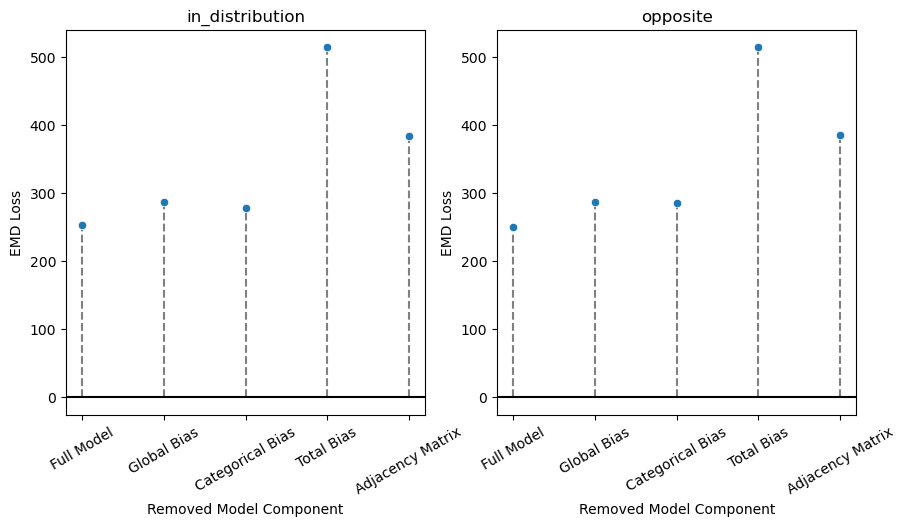

In [12]:
ncols = loss_res.shape[1]
fig, ax = plt.subplots(ncols = ncols, figsize = (ncols *5.1, 5))


xtick_map = {'none': 'Full Model', 
 'adj': 'Adjacency Matrix', 
 'total_bias': 'Total Bias', 
'categorical_bias': 'Categorical Bias', 
'global_bias': 'Global Bias', 
            'adj_categorical_bias': 'Adjacency Matrix and \n Categorical Bias', 
            'adj_global_bias': 'Adjacency Matrix and \n Global Bias'}

for i, counterfactual_type in enumerate(loss_res.columns):
    viz_df = loss_res[counterfactual_type].reset_index().rename(columns = {'index': 'Removed Model Component', 
                                                             counterfactual_type: 'EMD Loss'})
    viz_df['Removed Model Component'] = viz_df['Removed Model Component'].map(xtick_map)
    
    sns.scatterplot(data = viz_df, x = 'Removed Model Component', y = 'EMD Loss', ax = ax[i])
    
    for x, y in zip(viz_df['Removed Model Component'], viz_df['EMD Loss']):
        ax[i].vlines(x, ymin=0, ymax=y, linestyle='dashed', color='gray', zorder = 0)
    ax[i].axhline(y=0, color='black')
    ax[i].axhline(y=viz_df.set_index('Removed Model Component').loc['Full Model', 'EMD Loss'], 
               color='red', linestyle = 'dashed')
    
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right')

    ax[i].set_title(counterfactual_type)

## 1.2 Let's also get the losses on the individual fold models:

In [13]:
models_path = os.path.join(data_path, 'processed', 'models')

res_folds = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_k_fold_validation_results.csv'), index_col = 0)
best_emd_mean, best_hyperparams, best_emd = get_best_hyperparams(res_folds)
trainers_best = {k: io.read_pickled_object(os.path.join(models_path, 'Kang_best_trainer_' + str(k) + '.pickle')) for k in range(best_emd.shape[0])}


In [10]:
# loss_res_fold = {}

# for k, trainer_k in tqdm(trainers_best.items()):
#     mod_k = trainer_k.mod
#     train_cells_all_k = trainer_k.X_train.index.tolist()
#     cf_map_k = {'in_distribution': train_cells_all_k}
    
#     loss_res_fold[k] = {}
    
#     for counterfactual_type in counterfactual_types:#['opposite']:
#         loss_res_fold[k][counterfactual_type] = {}
#         for remove_type in remove_types_list:
#             tf_adata_predicted, tot_loss = get_prediction(mod = mod_k, 
#                                                           tf_adata = tf_adata, 
#                                                           counterfactual_type = counterfactual_type, 
#                                                           cf_map = cf_map_k, 
#                                                           train_cells_all = train_cells_all_k, 
#                                                           test_conds = test_conds, 
#                                                           remove_type = remove_type,
#                                                           return_bias = False, 
#                                                           return_loss = True, 
#                                                          test_cells = test_cells) 
#             if type(remove_type) == list:
#                 remove_type = '_'.join(remove_type)
#             loss_res_fold[k][counterfactual_type][remove_type] = tot_loss
            
            
# loss_res_fold_formatted = dict(zip(['in_distribution', 'opposite'], [[], []]))
# for k, inner_dict in loss_res_fold.items():
#     final_out = {'fold': k}
#     for counterfactual_type, inner_dict_2 in inner_dict.items():
#         for include_type, val in inner_dict_2.items():
#             final_out[include_type] = val
#         loss_res_fold_formatted[counterfactual_type].append(final_out)
        
# with open(os.path.join(data_path, 'processed', author + '_prediction_loss_folds.json'), 'w') as json_file:
#     json.dump(loss_res_fold_formatted, json_file, indent=4)
with open(os.path.join(data_path, 'processed', author + '_prediction_loss_folds.json'), 'r') as json_file:
    loss_res_fold_formatted = json.load(json_file)

/tmp/ipykernel_3133017/1665650936.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=30, ha='center')
/tmp/ipykernel_3133017/1665650936.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=30, ha='center')


''

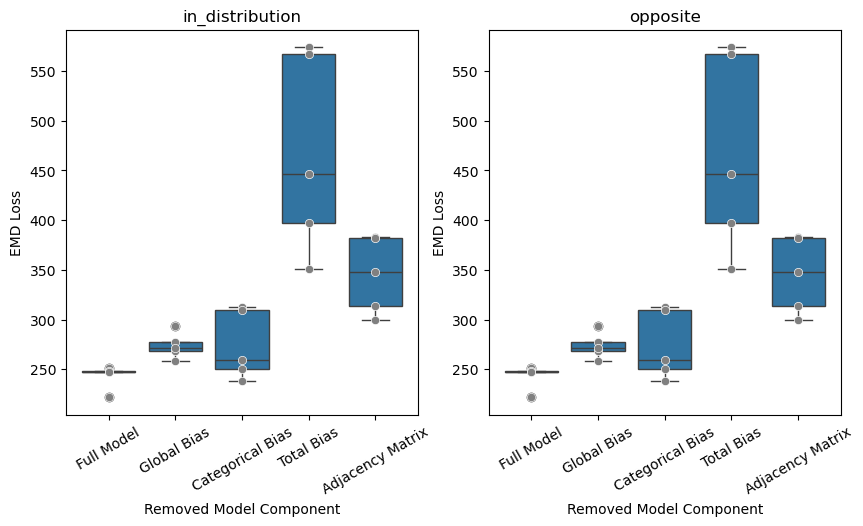

In [11]:
fig, ax = plt.subplots(ncols = 2, figsize = (10,5))

xtick_map = {'none': 'Full Model', 
 'adj': 'Adjacency Matrix', 
 'total_bias': 'Total Bias', 
'categorical_bias': 'Categorical Bias', 
'global_bias': 'Global Bias', 
            'adj_categorical_bias': 'Adjacency Matrix and \n Categorical Bias', 
            'adj_global_bias': 'Adjacency Matrix and \n Global Bias'}

for i, counterfactual_type in enumerate(['in_distribution', 'opposite']):
    viz_df = pd.DataFrame(loss_res_fold_formatted[counterfactual_type])
    
    viz_df = viz_df.melt(id_vars='fold', var_name='Removed Model Component', value_name='EMD Loss')
    viz_df['Removed Model Component'] = viz_df['Removed Model Component'].map(xtick_map)
    
    sns.boxplot(data = viz_df, x = 'Removed Model Component', y = 'EMD Loss', ax = ax[i], zorder = 0)
    sns.scatterplot(data = viz_df, x = 'Removed Model Component', y = 'EMD Loss', color = 'gray', ax = ax[i])
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=30, ha='center')
    ax[i].set_title(counterfactual_type)
;

Overall, we see that both the adjacency matrix and  bias contribute to prediction accuracy. However, it appears that total bias has a stronger contribution than the adjacency matrix, whereas the individual components of bias each have a weakr contribution. 